In [2]:
from fractions import Fraction
from pathlib import Path

import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from eeg_music.data import (
    ArrayStratifiedSamplingDataset,
    EEGMusicDataset,
    RepeatedDataset,
)

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [3]:
dataset_paths = {
    # "ICA": Path("./datasets/musing_preprocessed/musing_pre_60ch"),
    # "No ICA": Path("./datasets/musing_preprocessed/musing_alternative_id_60ch"),
    "Raw EEG" : Path("./datasets/musing_preprocessed/musing_basic_id_129ch"),
}

datasets = {name: EEGMusicDataset.load_ondisk(p) for name, p in dataset_paths.items()}
{name: len(ds) for name, ds in datasets.items()}

{'Raw EEG': 240}

In [4]:
def create_X_y(dataset):
    X, y = zip(*[
        (dataset[i].eeg_data.get_array().data, dataset[i].music_data.music_id.song_id - 1)
        for i in range(len(dataset))
    ])
    return np.array(X), np.array(y)

def create_data(train_ds, test_ds):
    X_train, y_train = create_X_y(train_ds)
    X_test, y_test = create_X_y(test_ds)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    print(f"Train: {X_train_flat.shape}, Test: {X_test_flat.shape}, Classes: {len(np.unique(y_train))}")
    return X_train_flat, X_test_flat, y_train, y_test

def train_model(name: str, model, X_train_flat, X_test_flat, y_train, y_test) -> float:
    print(f"Training {name}...")
    model.fit(X_train_flat, y_train)
    y_pred = model.predict(X_test_flat)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    return acc

In [ ]:
trial_length_secs = Fraction(1, 1)
n_strata = 10
num_repeats = 10

def make_strat(ds):
    return RepeatedDataset(
        ArrayStratifiedSamplingDataset(ds, n_strata=n_strata, trial_length_secs=trial_length_secs),
        num_repeats=num_repeats,
    )

def make_models():
    return {
        "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
        "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    }

accuracies = {}

for ds_name, ds in datasets.items():
    splitted = ds.subject_wise_split(p_train=0.6, p_val=0.0)
    train_ds, test_ds = splitted["train"], splitted["test"]
    train_strat, test_strat = make_strat(train_ds), make_strat(test_ds)
    X_train_flat, X_test_flat, y_train, y_test = create_data(train_strat, test_strat)

    for model_name, model in make_models().items():
        print(f"\n=== {ds_name} / {model_name} ===")
        acc = train_model(model_name, model, X_train_flat, X_test_flat, y_train, y_test)
        accuracies[(ds_name, model_name)] = acc

accuracies

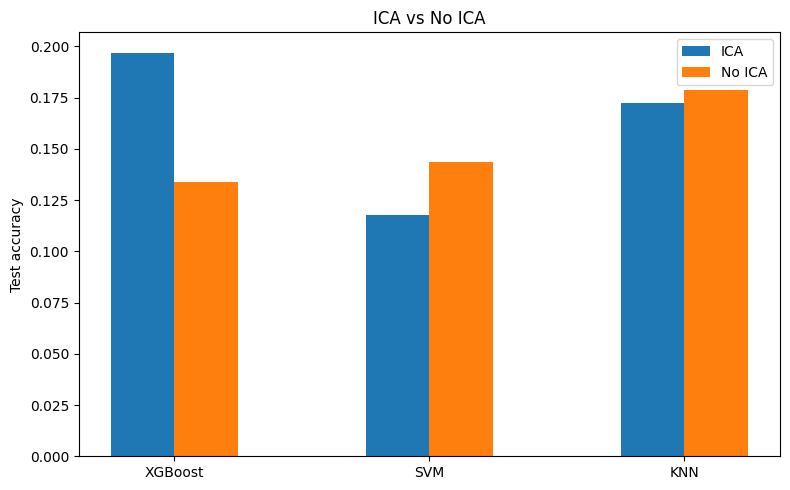

In [ ]:
import matplotlib.pyplot as plt

ds_names = list(dataset_paths.keys())
model_names = list(make_models().keys())

bar_width = 0.25
x = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(8, 5))
for i, ds_name in enumerate(ds_names):
    vals = [accuracies[(ds_name, m)] for m in model_names]
    ax.bar(x + i * bar_width, vals, bar_width, label=ds_name)

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(model_names)
ax.set_ylim(0, None)
ax.set_ylabel("Test accuracy")
ax.set_title("ICA vs No ICA")
ax.legend()
plt.tight_layout()
plt.show()